# Import

In [1]:
import yfinance as yf
from datetime import datetime
import numpy as np
import pandas as pd

import sys, importlib, os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils
from torch.utils.data import DataLoader
from typing import Tuple
import yaml
from pathlib import Path
from datetime import datetime

from torchvision import datasets, transforms
from torch.utils.data import Subset

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

import pytorch_lightning as pl

In [2]:
# Importing project packages
cwd = Path(os.getcwd())
root_dir = cwd.parent

utils_dir = root_dir.joinpath('src','utils')
model_dir = root_dir.joinpath('src','model')

sys.path.append(str(root_dir))

In [3]:
from src.utils import WIP_SDE, WIP_processes
from src.models import components




importlib.reload(WIP_SDE)
importlib.reload(WIP_processes)
importlib.reload(components)

from src.utils.WIP_SDE import VESDE, SubVPSDE, VPSDE
from src.utils.WIP_processes import Diffusion_Processes
from src.training.ldm_module import LDMLightningModule
# from src.models.components import SinusoidalPositionEmbeddings # Required by unet_model
from src.models.UNet import UNet

importlib.reload(sys.modules['src.training.ldm_module'])
importlib.reload(sys.modules['src.models.UNet'])

device = torch.device("cpu")
# unet = UNet

In [4]:
cfg = {
    'N': 1000,
    'sde_type': 've', # or 've' / 'subvp'
    'channels': 5,    # Vital: Match your blob channel count
    # 'image_size': 32,
    'features': [128, 256, 512],
    'batch_size': 16,
    'vae_scale_factor': 0.18125,
    'learning_rate': 0.001,
    'epochs': 10,
    'channels': 5,
    'features': [128, 256, 512],
    'eps': 1e-6,
    'conditional': False
}

# Data download

In [5]:
ticker = "AAPL"
start_date = "2010-01-01"
end_date = "2024-12-31"

In [6]:
data = yf.download(
    tickers = ticker,
    start = start_date,
    end = end_date,
    interval = "1d",
    auto_adjust = True,
    progress = False
)

In [7]:
print(data.head())

Price          Close      High       Low      Open     Volume
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL
Date                                                         
2010-01-04  6.418385  6.433081  6.369500  6.400990  493729600
2010-01-05  6.429480  6.465769  6.395589  6.436078  601904800
2010-01-06  6.327211  6.454973  6.320613  6.429481  552160000
2010-01-07  6.315514  6.358101  6.269627  6.350604  477131200
2010-01-08  6.357500  6.358100  6.269927  6.307115  447610800


# Quick data overview

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   3773 non-null   float64
 1   (High, AAPL)    3773 non-null   float64
 2   (Low, AAPL)     3773 non-null   float64
 3   (Open, AAPL)    3773 non-null   float64
 4   (Volume, AAPL)  3773 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB


In [16]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,3773.000000,3773.000000,3773.000000,3773.000000,3.773000e+03
mean,67.243348,67.895073,66.521444,67.186811,2.299696e+08
std,65.320571,65.927285,64.623759,65.240373,2.180792e+08
min,5.759780,5.878244,5.705796,5.769377,2.323470e+07
25%,17.401424,17.579165,17.256840,17.402002,8.492380e+07
50%,35.164116,35.579204,34.842792,35.216410,1.405608e+08
75%,126.455147,127.539115,124.212859,125.760324,3.081512e+08
max,257.853760,258.928914,256.470034,257.027510,1.880998e+09


Daily Return Statistics:
count    3772.000000
mean        0.001127
std         0.017554
min        -0.128647
25%        -0.007401
50%         0.001004
75%         0.010356
max         0.119808
Name: daily_return, dtype: float64


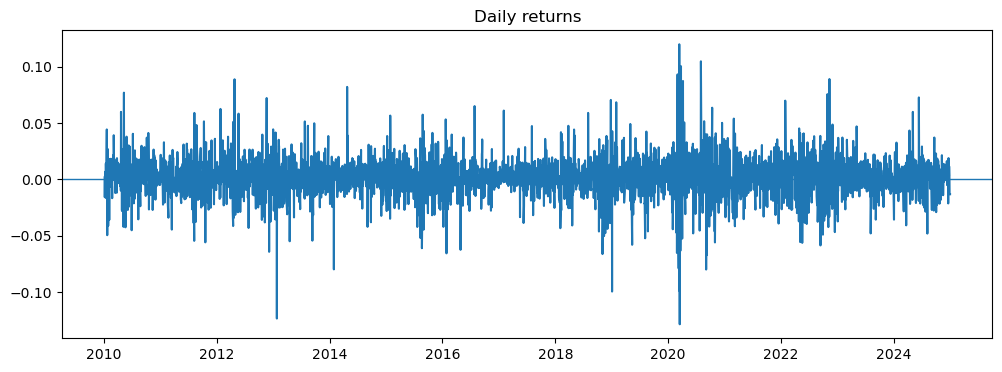

In [17]:
df = data.copy()
df = df.sort_index()

df['daily_return'] = df['Close'].pct_change()

print("Daily Return Statistics:")
print(df['daily_return'].describe())

plt.figure(figsize=(12,4))
plt.plot(df.index, df['daily_return'])
plt.axhline(0, linewidth=1)
plt.title("Daily returns")
plt.show()

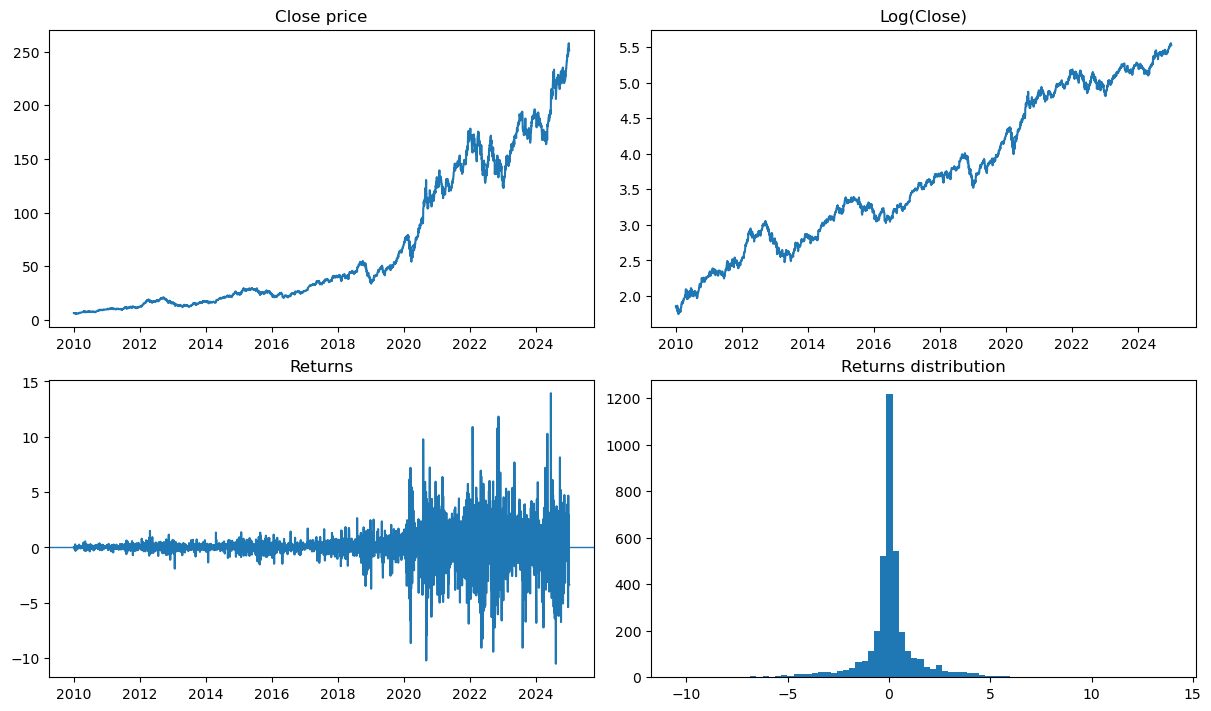

In [18]:
df = data.copy()
df = df.sort_index()

# --- pick Close/Volume robustly (works with single- or multi-index columns) ---
if isinstance(df.columns, pd.MultiIndex):
    # common yfinance-style: level 0 = field (Close/Open/...), level 1 = ticker
    close = df.xs("Close", axis=1, level=0)
    vol   = df.xs("Volume", axis=1, level=0) if ("Volume" in df.columns.get_level_values(0)) else None
else:
    close = df["Close"]
    vol   = df["Volume"] if "Volume" in df.columns else None

# if you have multiple tickers, pick one:
if hasattr(close, "columns"):
    tkr = close.columns[0]          # e.g., "AAPL"
    close = close[tkr]
    vol = vol[tkr] if vol is not None and hasattr(vol, "columns") else vol

# --- log price + returns ---
logp = np.log(close)
ret  = close.diff().dropna()         # log returns

# --- quick trend/distribution dashboard ---
fig, ax = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

ax[0,0].plot(close)
ax[0,0].set_title("Close price")

ax[0,1].plot(logp)
ax[0,1].set_title("Log(Close)")

ax[1,0].plot(ret)
ax[1,0].axhline(0, linewidth=1)
ax[1,0].set_title("Returns")

ax[1,1].hist(ret, bins=80)
ax[1,1].set_title("Returns distribution")

plt.show()


## Intra-day Features

In [19]:
df['hl_range'] = (df['High'] - df['Low']) / df['Open']        # normalized range
df['oc_return'] = (df['Close'] - df['Open']) / df['Open']    # intraday return
df['log_return'] = np.log(df['Close']).diff()
df['log_volume'] = np.log(df['Volume'])

In [20]:
cols = ['hl_range', 'oc_return', 'log_return', 'log_volume']
corr = df[cols].corr()
corr

,Price,hl_range,oc_return,log_return,log_volume
,Ticker,,,,
Price,Ticker,,,,
hl_range,,1.000000,-0.019019,-0.101175,0.303324
oc_return,,-0.019019,1.000000,0.750330,-0.067890
log_return,,-0.101175,0.750330,1.000000,-0.030830
log_volume,,0.303324,-0.067890,-0.030830,1.000000


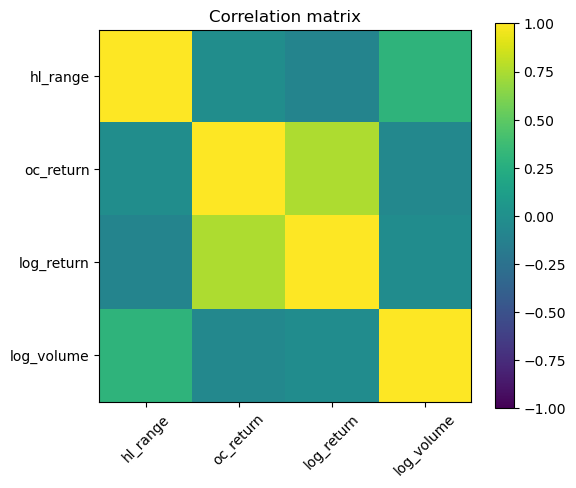

In [21]:
plt.figure(figsize=(6,5))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(cols)), cols, rotation=45)
plt.yticks(range(len(cols)), cols)
plt.title("Correlation matrix")
plt.show()


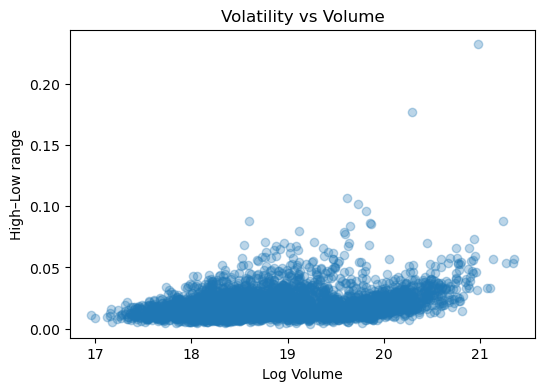

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(df['log_volume'], df['hl_range'], alpha=0.3)
plt.xlabel("Log Volume")
plt.ylabel("High–Low range")
plt.title("Volatility vs Volume")
plt.show()


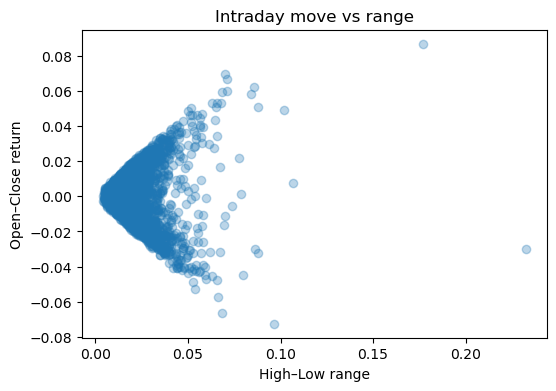

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(df['hl_range'], df['oc_return'], alpha=0.3)
plt.xlabel("High–Low range")
plt.ylabel("Open–Close return")
plt.title("Intraday move vs range")
plt.show()


## Autocorrelation

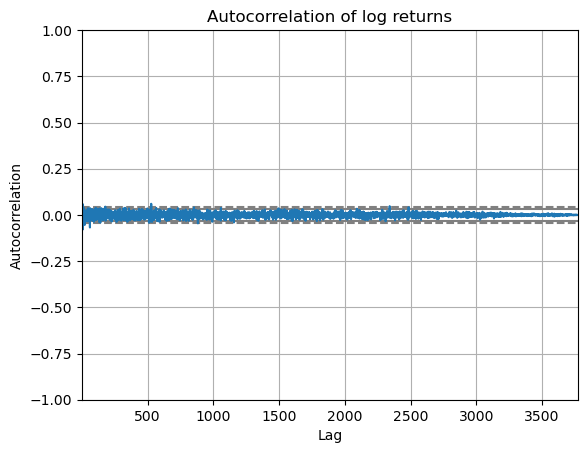

In [24]:
from pandas.plotting import autocorrelation_plot

autocorrelation_plot(df['log_return'].dropna())
plt.title("Autocorrelation of log returns")
plt.show()


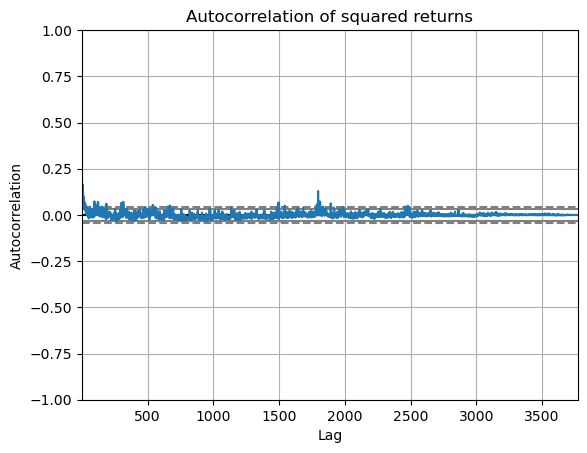

In [25]:
autocorrelation_plot(df['log_return'].dropna()**2)
plt.title("Autocorrelation of squared returns")
plt.show()


## Candle (OHLC) Graph

In [26]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

c:\Users\Lenovo\anaconda3\envs\thesis\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


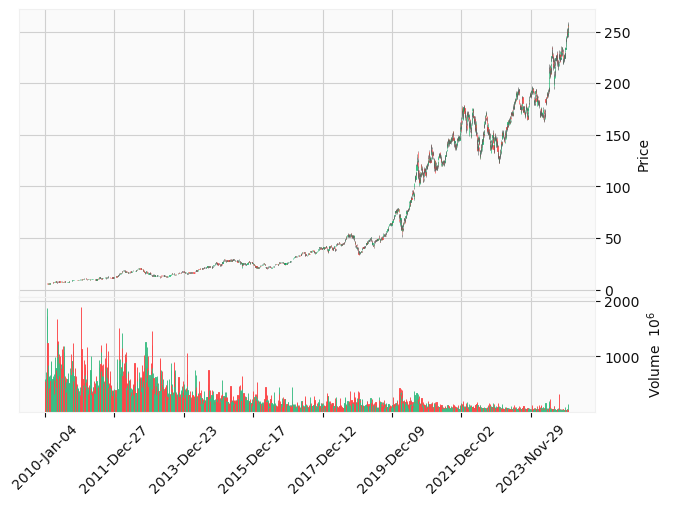

In [27]:
import mplfinance as mpf

df = df.copy().sort_index()
df.columns = df.columns.droplevel('Ticker')

mpf.plot(
    df[['Open','High','Low','Close','Volume']].astype(float),
    type='candle',
    volume=True,
    style='yahoo'
)


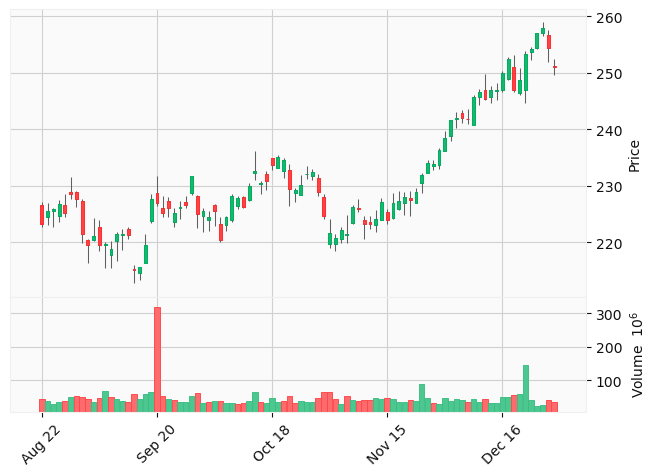

In [28]:
mpf.plot(
    df.iloc[-90:][['Open','High','Low','Close','Volume']],
    type='candle',
    volume=True,
    style='yahoo'
)


In [29]:
df[['hl_range','oc_return','log_return']].describe(percentiles=[.01,.05,.95,.99])


Price,hl_range,oc_return,log_return
count,3773.000000,3773.000000,3772.000000
mean,0.019871,0.000445,0.000972
std,0.011791,0.013696,0.017561
min,0.004138,-0.072579,-0.137708
1%,0.005950,-0.035206,-0.047423
5%,0.007884,-0.022279,-0.026902
50%,0.017094,0.000675,0.001004
95%,0.040278,0.021718,0.027222
99%,0.059184,0.035669,0.047586
max,0.232439,0.086961,0.113157


# Parameters

In [30]:
df = df.copy()

df = df.reset_index()     # Date becomes a column
# df = df.rename(columns={'Date': 'Date'})  # optional

df.columns.name = None    # remove "Price" label if present

df.describe()

,Date,Close,High,Low,Open,Volume,hl_range,oc_return,log_return,log_volume
count,3773,3773.000000,3773.000000,3773.000000,3773.000000,3.773000e+03,3773.000000,3773.000000,3772.000000,3773.000000
mean,2017-07-01 04:17:14.296315648,67.243348,67.895073,66.521444,67.186811,2.299696e+08,0.019871,0.000445,0.000972,18.897501
min,2010-01-04 00:00:00,5.759780,5.878244,5.705796,5.769377,2.323470e+07,0.004138,-0.072579,-0.137708,16.961157
25%,2013-10-02 00:00:00,17.401424,17.579165,17.256840,17.402002,8.492380e+07,0.012377,-0.007042,-0.007428,18.257265
50%,2017-06-30 00:00:00,35.164116,35.579204,34.842792,35.216410,1.405608e+08,0.017094,0.000675,0.001004,18.761151
75%,2021-03-31 00:00:00,126.455147,127.539115,124.212859,125.760324,3.081512e+08,0.024106,0.008403,0.010303,19.546101
max,2024-12-30 00:00:00,257.853760,258.928914,256.470034,257.027510,1.880998e+09,0.232439,0.086961,0.113157,21.355068
std,NaN,65.320571,65.927285,64.623759,65.240373,2.180792e+08,0.011791,0.013696,0.017561,0.826068


# Transformation of data

In [31]:
# 1. Ensure Temporal Order
# Use the 'Date' column to sort but do not include it in the numerical tensor
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 2. Universal Anchor Transformation (Stationarity)
# We divide ALL price features at time 't' by the Close at 't-1'
prev_close = df['Close'].shift(1)
ohlc_cols = ['Open', 'High', 'Low', 'Close']

# Log-returns for prices: r_t = ln(Price_t / Close_{t-1})
ohlc_log_rets = np.log(df[ohlc_cols].div(prev_close, axis=0))

# 3. Independent Volume Processing
# Volume is a different unit; normalize it by its own previous value
volume_log_rets = np.log(df['Volume'] / df['Volume'].shift(1))

# 4. Clean and Standardize (Z-Score)
# Diffusion models require unit variance (std=1) to prevent gradient collapse
processed_df = pd.concat([ohlc_log_rets, volume_log_rets], axis=1).dropna()
data_array = processed_df.values.astype(np.float32)

# Global standardization using training set statistics
mean = data_array.mean(axis=0)
std = data_array.std(axis=0)
data_standardized = (data_array - mean) / (std + 1e-6)

print(f"Before Standardization: mean={data_array.mean():4f}, std={data_array.std():4f}")
print(f"After Standardization: mean={data_standardized.mean():4f}, std={data_standardized.std():4f}")

print("\nBefore standardization:")
for i in range(data.shape[1]):
    col_mean = data_array[:, i].mean()
    col_std = data_array[:, i].std()
    print(f"Feature {i}: mean={col_mean: .6f}, std={col_std: .6f}")

# 5. Tensor Preparation for 1D-UNet
# Shape must be (Batch, Channels, Length) -> (M, 5, 252)
N = 252 # Sequence length representing one trading year
M = len(data_standardized) // N

# Reshape and Permute: moves features from columns to channels
train_tensor = torch.tensor(data_standardized[:M*N]).view(M, N, 5).permute(0, 2, 1)

print(f"Tensor Shape: {train_tensor.shape}") # Output: torch.Size([M, 5, 252])

Before Standardization: mean=0.000392, std=0.140737
After Standardization: mean=-0.000000, std=0.999943

Before standardization:
Feature 0: mean= 0.000621, std= 0.011606
Feature 1: mean= 0.010475, std= 0.013396
Feature 2: mean=-0.009412, std= 0.015412
Feature 3: mean= 0.000972, std= 0.017558
Feature 4: mean=-0.000697, std= 0.313011
Tensor Shape: torch.Size([14, 5, 252])


# Forward

In [32]:
diffusion = Diffusion_Processes(cfg)

In [33]:
# def forward_diffusion_gbm(x0, t, sigma_min=0.01, sigma_max=1.0):
#     """Simple VE-SDE forward step (corresponds to GBM in price space)"""
#     # Exponential schedule as suggested in the paper
#     sigma_t = sigma_min * (sigma_max / sigma_min)**t
#     noise = np.random.normal(size=x0.shape)
#     xt = x0 + sigma_t * noise
#     return xt, sigma_t

In [34]:
def summarize_and_plot(name, z):
    # flatten to 1D
    z_flat = z.detach().cpu().flatten()

    # statistics
    mean = z_flat.mean()
    std = z_flat.std(unbiased=False)

    z_standard = (z_flat - mean) / std
    skew = torch.mean(z_standard ** 3)
    kurt = torch.mean(z_standard ** 4)

    # print stats
    print(f"{name} statistics:")
    print(f"mean      = {mean.item():.6f}")
    print(f"std       = {std.item():.6f}")
    print(f"skew      = {skew.item():.6f}")
    print(f"kurtosis  = {kurt.item():.6f}")
    print()

    # histogram
    plt.figure(figsize=(6,4))
    plt.hist(z_flat.numpy(), bins=100, density=True)
    plt.title(f"Histogram of {name}")
    plt.xlabel(name)
    plt.ylabel("density")
    plt.show()

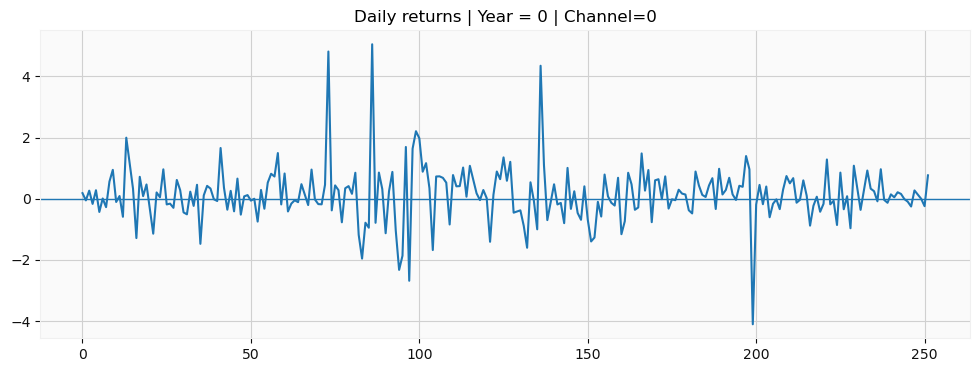

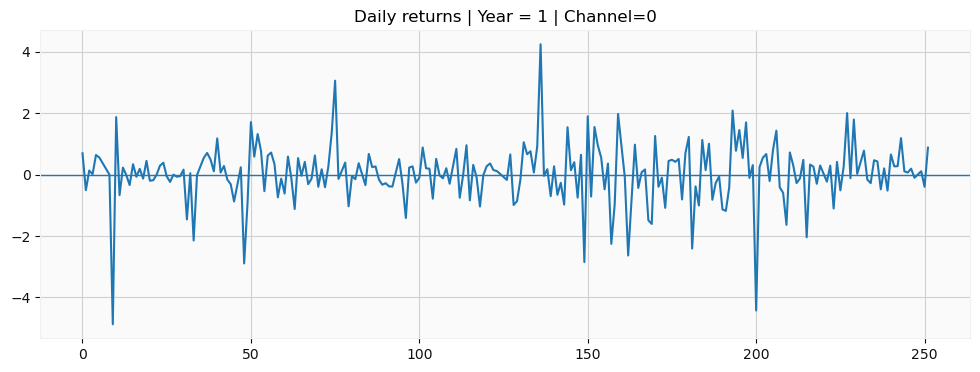

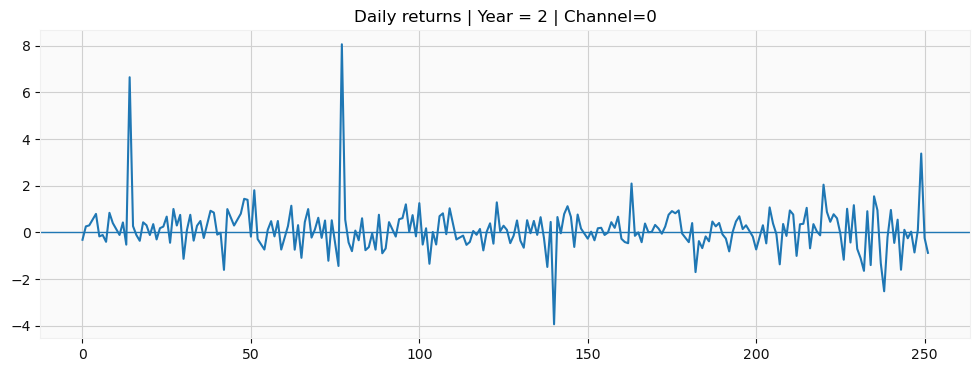

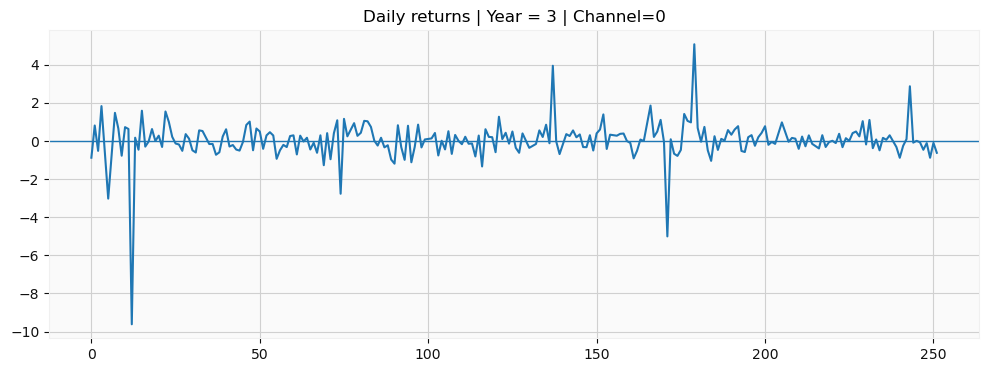

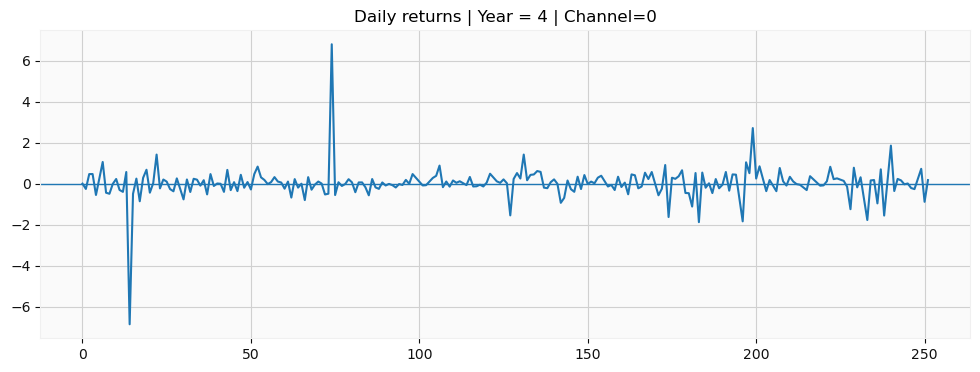

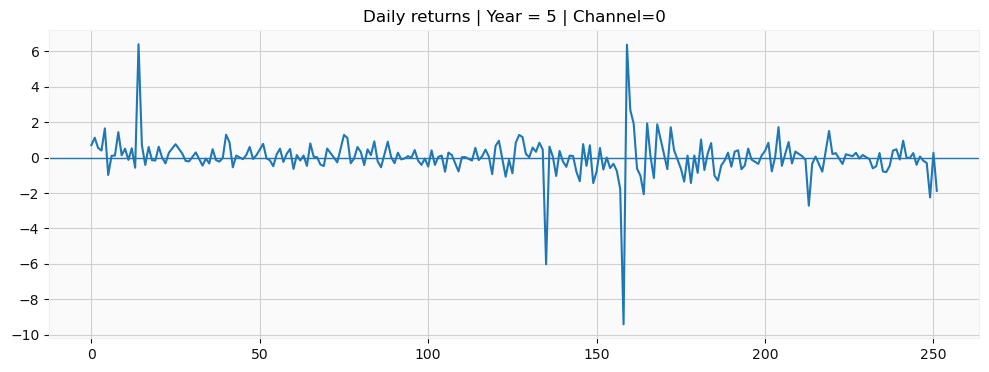

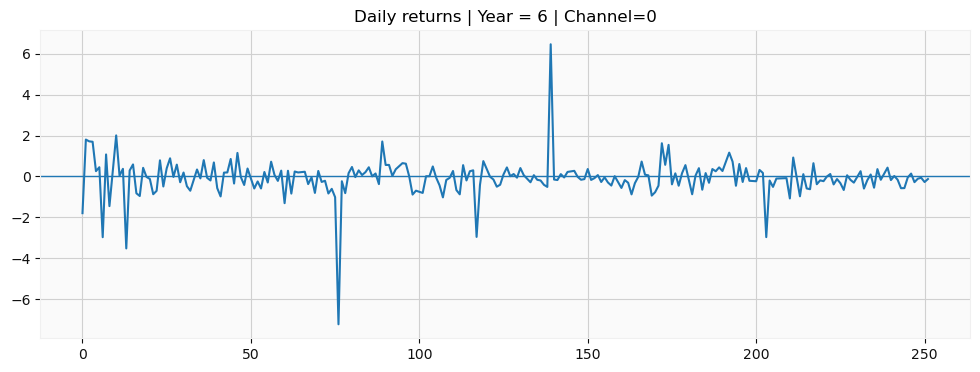

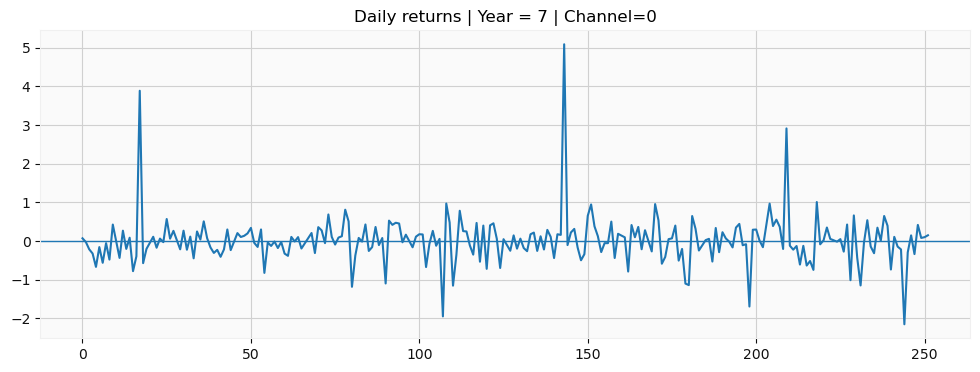

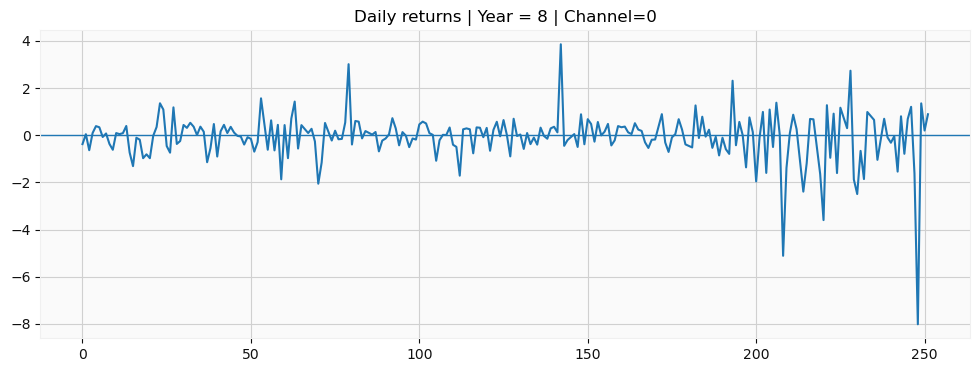

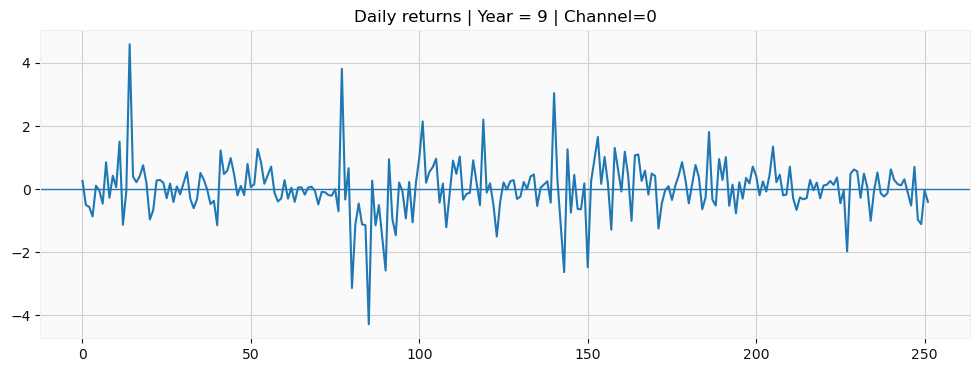

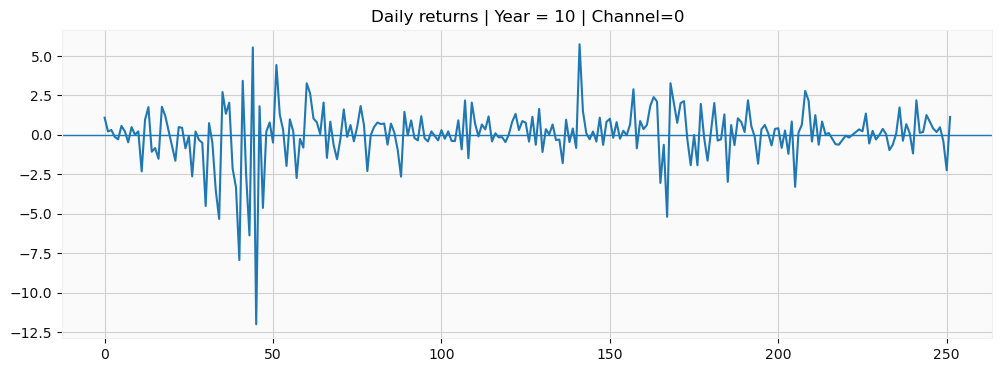

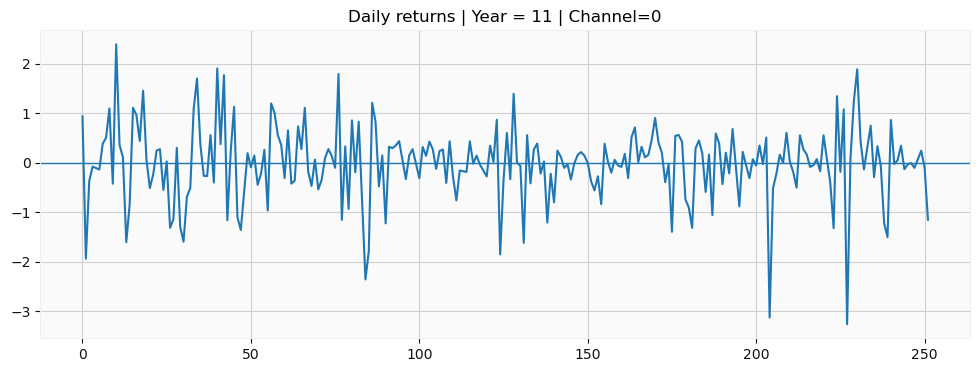

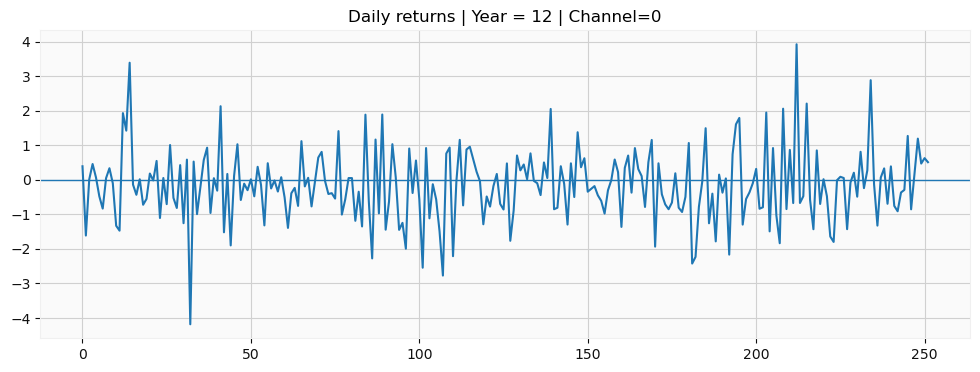

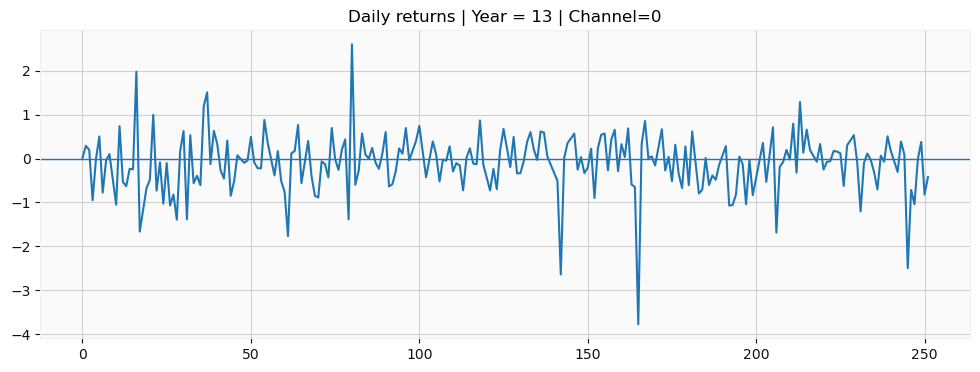

In [35]:
ch = 0
for i in range(train_tensor.size(0)):
    year = i
    x = train_tensor[year,ch,:].detach().cpu().numpy()
    plt.figure(figsize=(12,4))
    plt.plot(x)
    plt.axhline(0, linewidth=1)
    plt.title(f"Daily returns | Year = {year} | Channel={ch}")
    plt.show()


In [36]:
xt, t, eps = diffusion.forward_process(train_tensor)

Noisy data xt statistics:
mean      = -0.015715
std       = 9.294559
skew      = -0.023636
kurtosis  = 30.212801



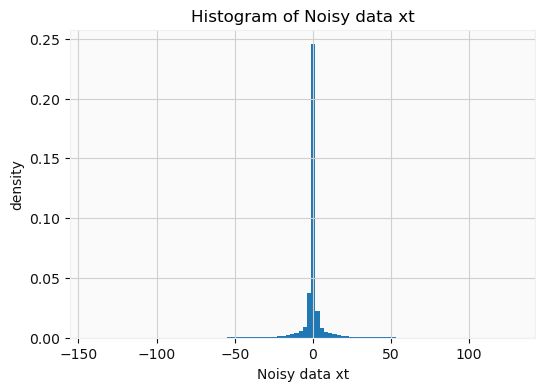

In [37]:
summarize_and_plot("Noisy data xt", xt)

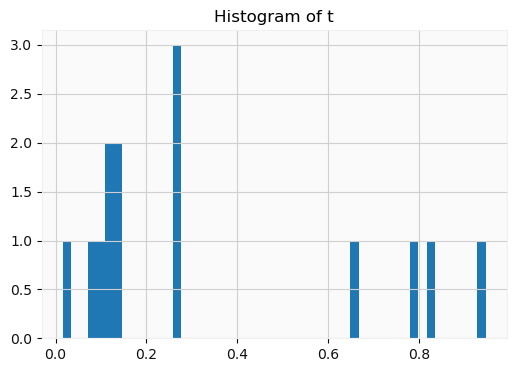

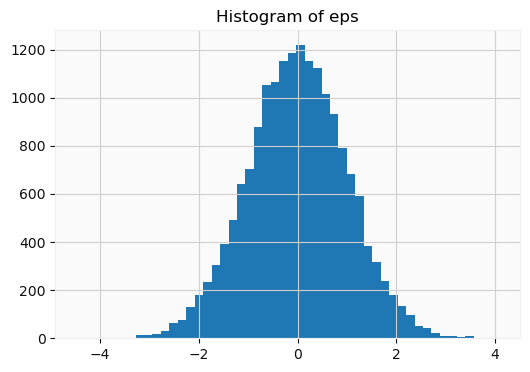

In [38]:
t_cpu = t.detach().cpu().flatten()
eps_cpu = eps.detach().cpu().flatten()

plt.figure(figsize=(6,4))
plt.hist(t_cpu, bins=50)
plt.title("Histogram of t")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(eps_cpu, bins=50)
plt.title("Histogram of eps")
plt.show()

## All progressed to `t=T`

In [39]:
times = torch.ones(train_tensor.size(0))
xt_final, t_final, eps_final = diffusion.forward_process(train_tensor, times)

Noisy data xt, all t=T statistics:
mean      = 0.678917
std       = 49.724037
skew      = 0.005348
kurtosis  = 2.993557



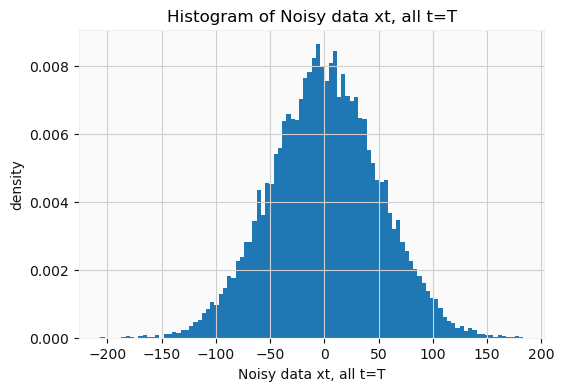

In [40]:
summarize_and_plot("Noisy data xt, all t=T", xt_final)

In [41]:
xt_final.shape

torch.Size([14, 14, 5, 252])

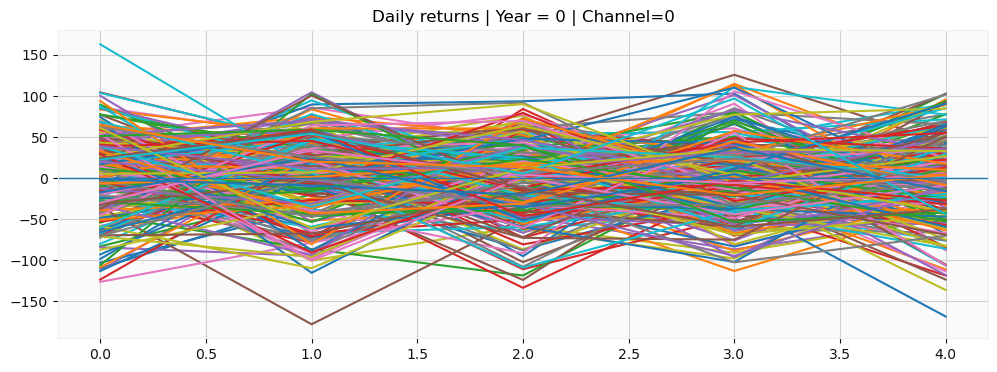

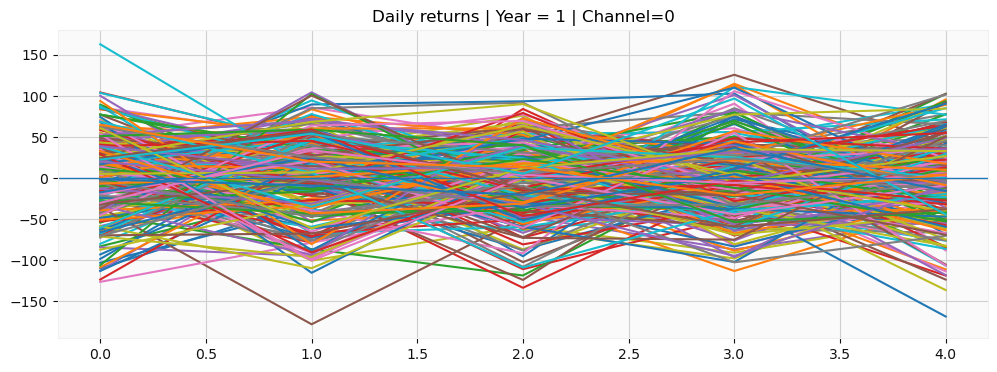

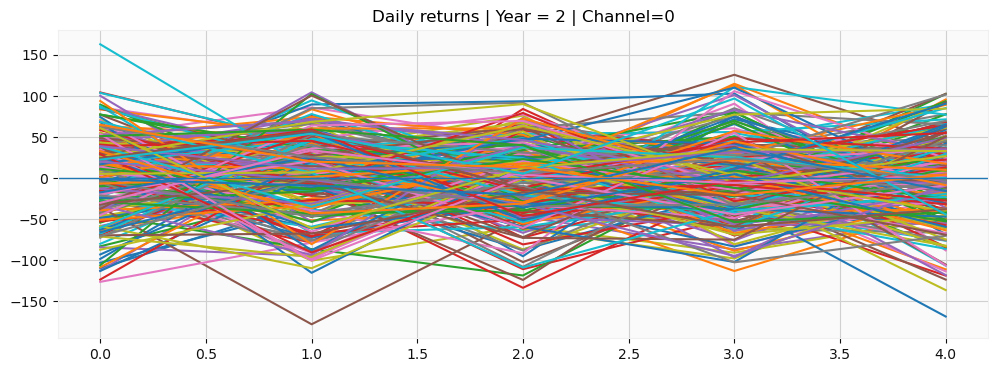

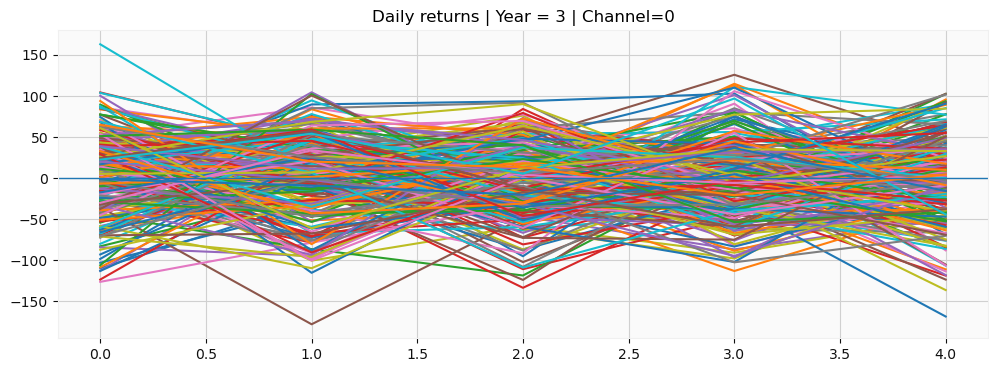

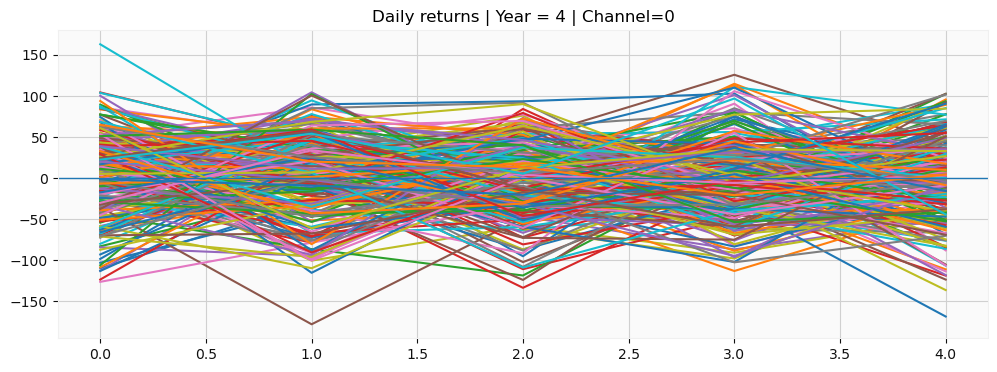

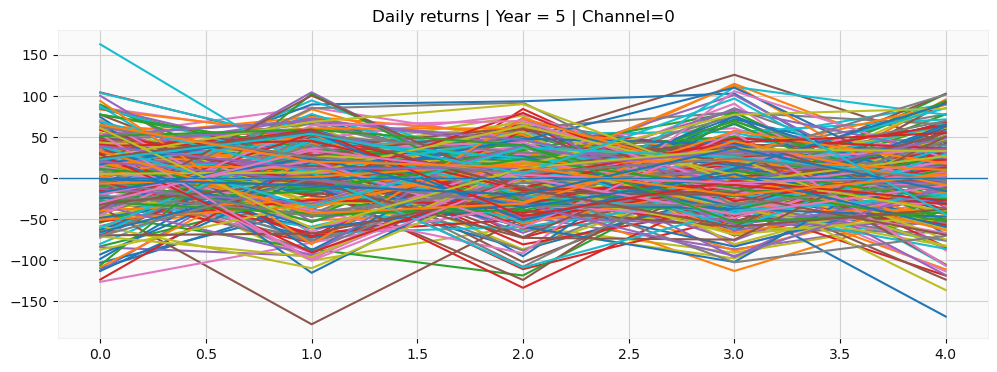

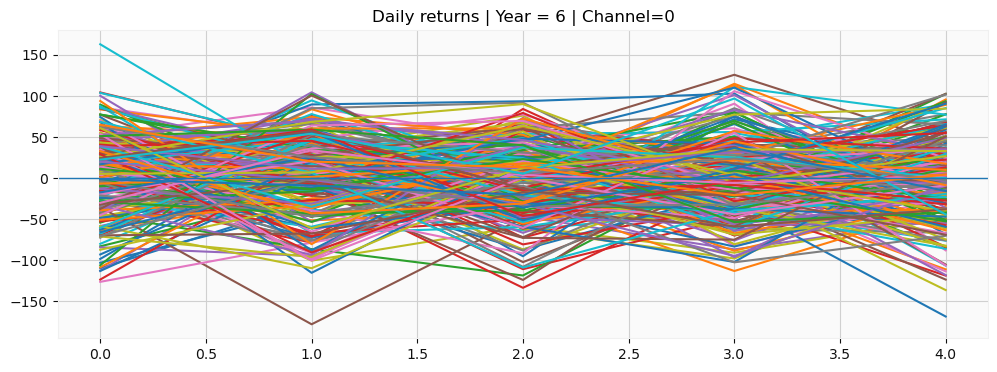

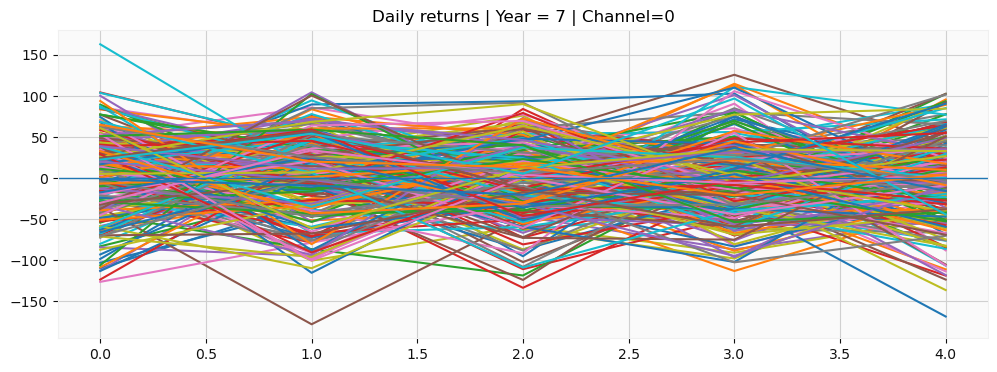

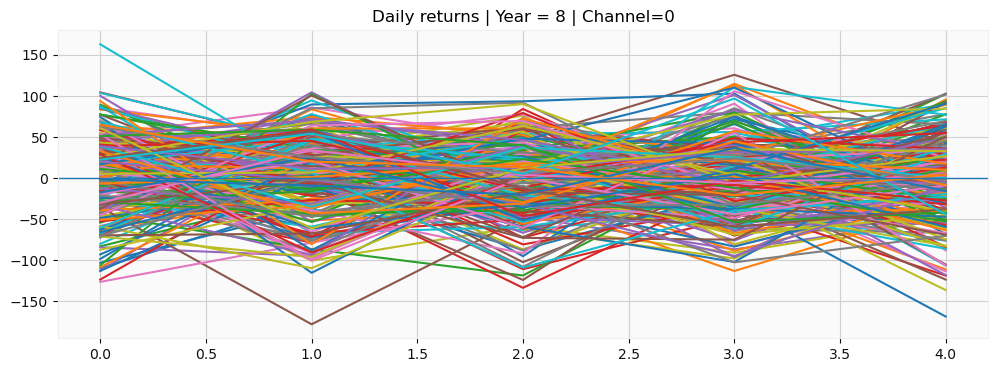

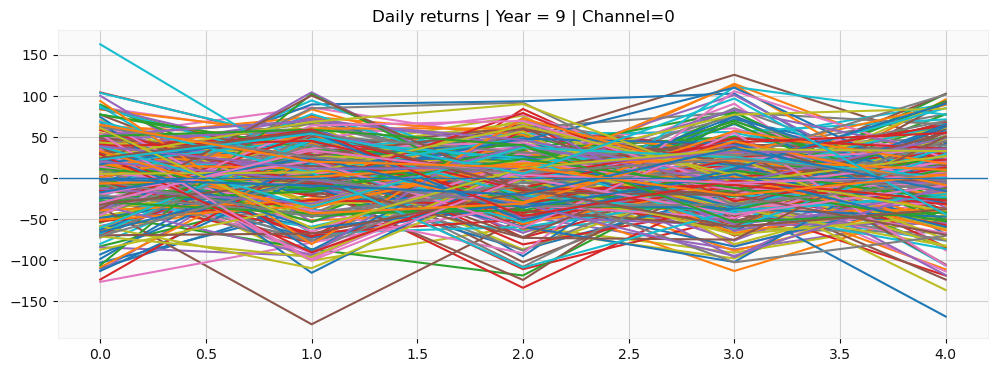

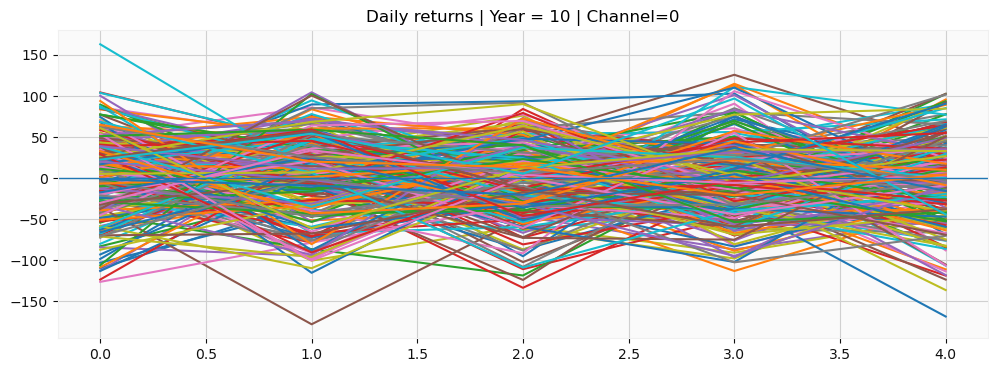

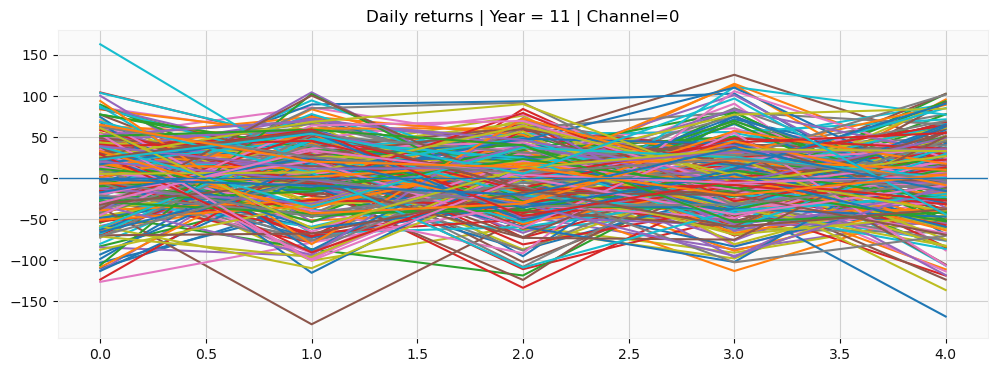

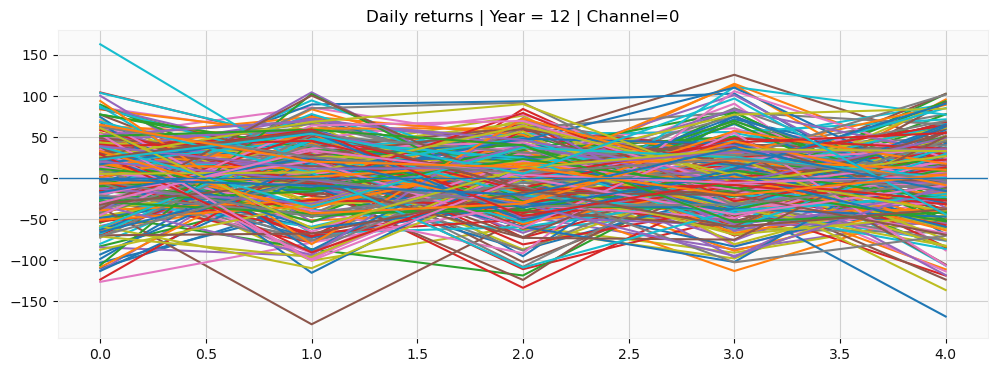

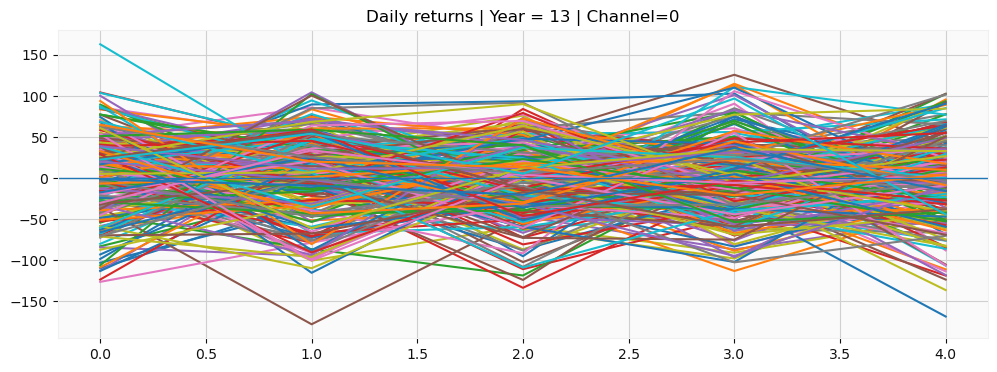

In [42]:
ch = 0

for i in range(xt_final.size(0)):
    year = i
    x = xt_final[year,ch,:].detach().cpu().numpy()
    plt.figure(figsize=(12,4))
    plt.plot(x)
    plt.axhline(0, linewidth=1)
    plt.title(f"Daily returns | Year = {year} | Channel={ch}")
    plt.show()


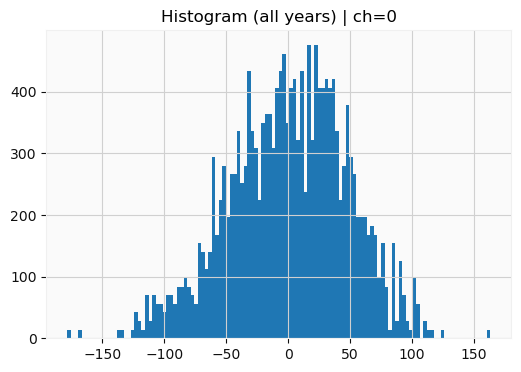

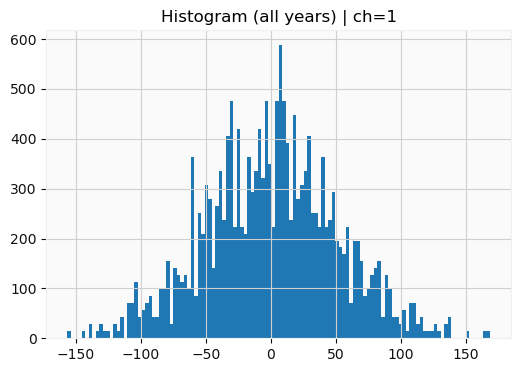

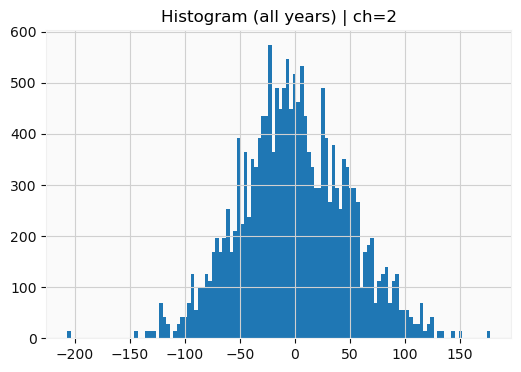

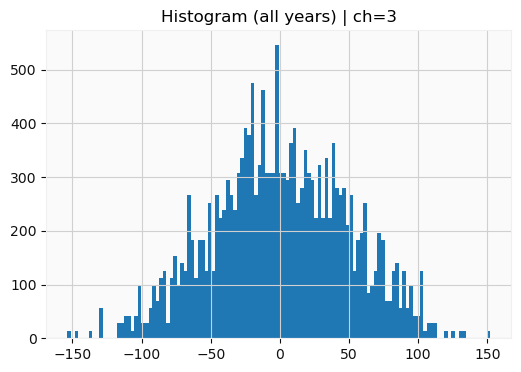

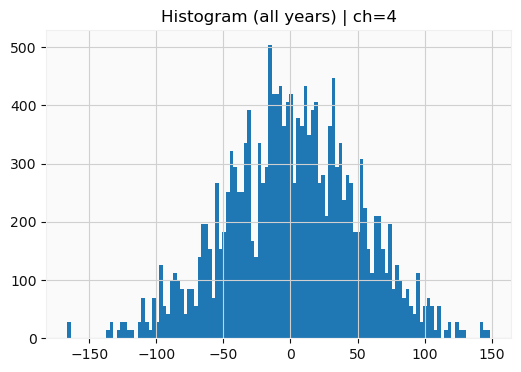

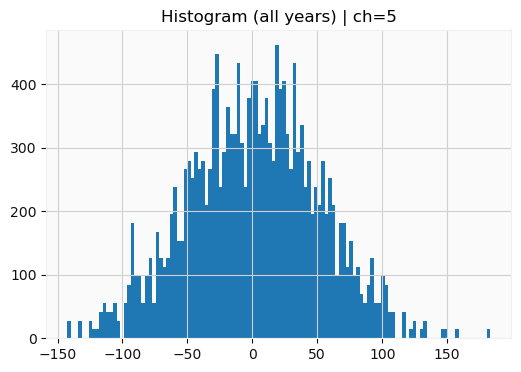

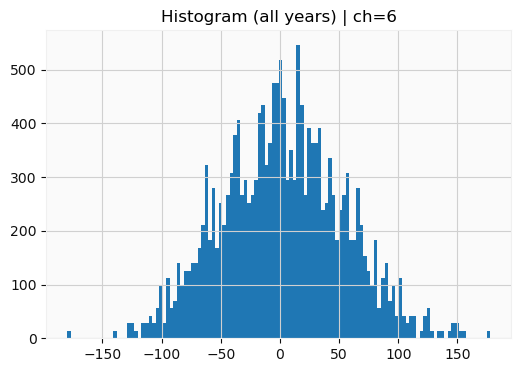

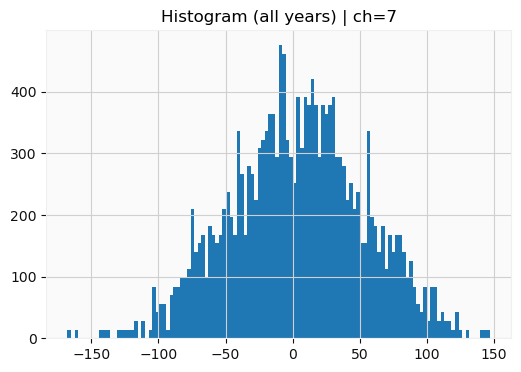

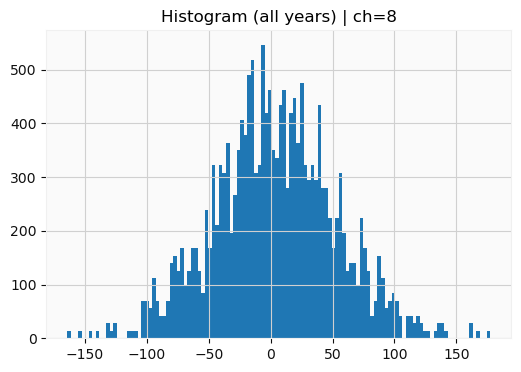

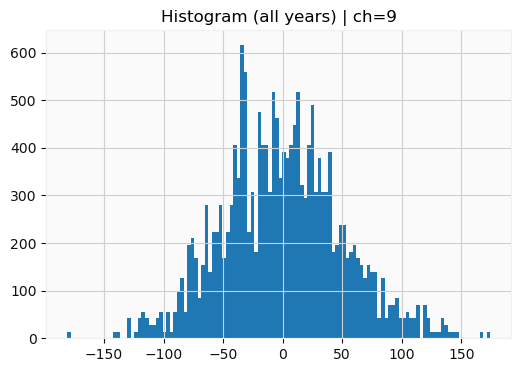

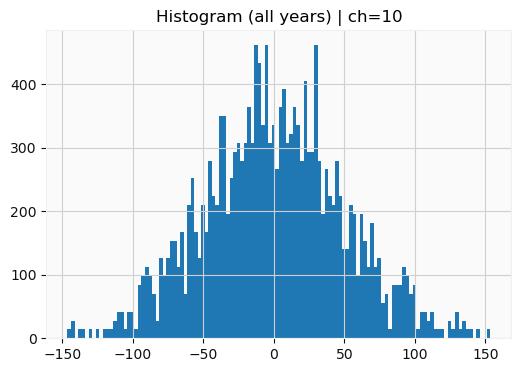

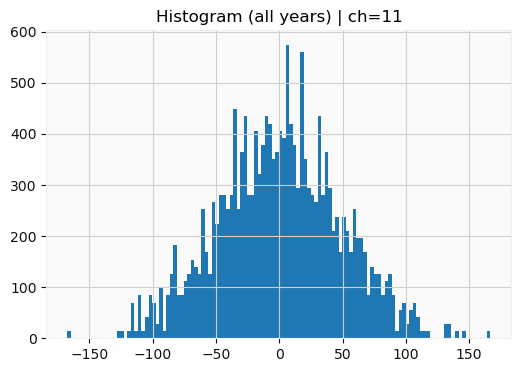

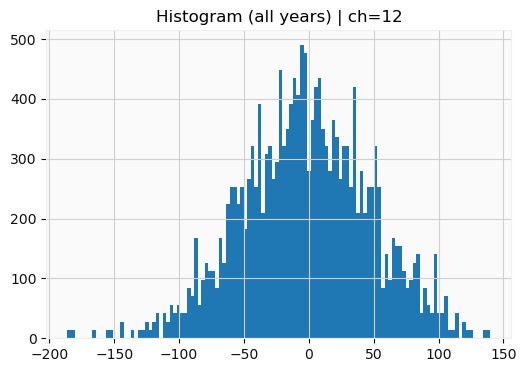

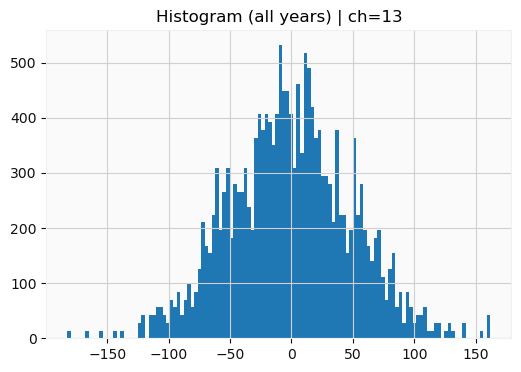

In [43]:
for ch in range(xt_final.size(1)):
    x_all = xt_final[:, ch, :].detach().cpu().numpy().ravel()

    plt.figure(figsize=(6,4))
    plt.hist(x_all, bins=120)
    plt.title(f"Histogram (all years) | ch={ch}")
    plt.show()

# Training and Model

In [79]:
hparams = {
        'learning_rate': cfg['learning_rate'],
        'n_timesteps': cfg['N'],
        'batch_size': cfg['batch_size'],
        'vae_scale_factor': cfg['vae_scale_factor'],
        'is_probabilities': None
    }

In [80]:
unet = UNet()

ldm_module = LDMLightningModule(
    unet_model=unet,
    forward_process=diffusion,
    vae_encoder=None,
    vae_decoder=None,
    hparams=hparams,
    cfg=cfg
)

In [81]:
print("n_trainable =", sum(p.numel() for p in ldm_module.parameters() if p.requires_grad))

n_trainable = 15294372


In [82]:
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split

# train_tensor: [N, ...] where N is number of samples (years/windows/etc.)
dataset = TensorDataset(train_tensor)   # each batch item is (x,)

# --- split train/val ---
val_frac = cfg.get("val_frac", 0.2)
n = len(dataset)
n_val = int(n * val_frac)
n_train = n - n_val

train_ds, val_ds = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.get("seed", 42))
)

# --- loaders ---
batch_size = cfg["batch_size"]
num_workers = cfg.get("num_workers", 0)

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,     # common for diffusion/AE training
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

# --- Lightning ---
trainer = pl.Trainer(
    max_epochs=cfg["epochs"],
    accelerator="auto",
    devices=1,
    logger=False,
    enable_checkpointing=False,
)

trainer.fit(ldm_module, train_dataloaders=train_loader, val_dataloaders=val_loader)
print("Final training loss:", trainer.callback_metrics.get("train_loss_epoch"))
print("Final validation loss:", trainer.callback_metrics.get("val_loss"))


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | unet      | UNet    | 15.3 M | train
1 | criterion | MSELoss | 0      | train
----------------------------------------------
15.3 M    Trainable params
0         Non-trainable params
15.3 M    Total params
61.177    Total estimated model params size (MB)
309       Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

AttributeError: 'list' object has no attribute 'shape'

# Reverse Process